# Quickstart: Symbolic Regression

Recover the ideal gas law $V = nRT / P$ from measurements using DRAGON's
DAG-based evolutionary search.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys, os
from pathlib import Path

notebook_dir = Path().resolve()
repo_root = notebook_dir.parents[2] if notebook_dir.name == "SymbolicRegression" else notebook_dir
lib_dir = repo_root / "lib"
if str(lib_dir) not in sys.path:
    sys.path.insert(0, str(lib_dir))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

## 1. Generate Data

In [2]:
R  = 8.314
n_samples = 2000
rng = np.random.default_rng(42)

P  = rng.uniform(1e4, 1e6, n_samples)
nc = rng.uniform(0.1, 10,  n_samples)
T  = rng.uniform(200, 1000, n_samples)

X = pd.DataFrame({"P": P, "n": nc, "T": T})
y = pd.Series(nc * R * T / P, name="V")

print(f"X shape: {X.shape},  y range: [{y.min():.2f}, {y.max():.2f}]")
X.head()

X shape: (2000, 3),  y range: [0.00, 4.87]


,P,n,T
0,776216.488070,8.443046,772.879977
1,444489.655355,4.519256,485.692477
2,860011.940712,9.534454,881.494285
3,700394.348769,6.542866,392.781728
4,103235.574409,1.247399,630.714792


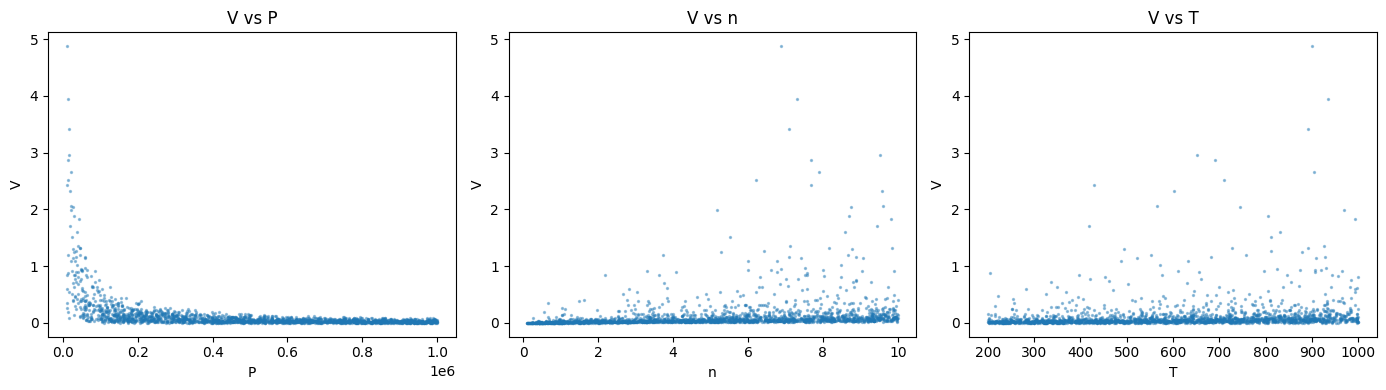

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, X.columns):
    ax.scatter(X[col], y, s=2, alpha=0.4)
    ax.set_xlabel(col)
    ax.set_ylabel("V")
    ax.set_title(f"V vs {col}")
plt.tight_layout()
plt.show()

## 2. Feature Selection

In [4]:
from dragon.utils.symbolic.features_selection import GradientBoostingSelector, CombinationBuilder

selector = GradientBoostingSelector(n_top=3, model_type="xgboost")
top_features, scores = selector.fit_transform(X, y)
num_features = len(top_features)

print("Top features:", top_features)
print("Scores:", {k: round(v, 4) for k, v in scores.items()})

Top features: ['P', 'n', 'T']
Scores: {'P': 0.735, 'n': 0.1909, 'T': 0.0741}


## 3. Build the Search Space

In [5]:
from dragon.search_space.bricks import (
    Identity, SelectFeatures, Inverse, Negate, Power,
    SumFeatures, ConstantBrick, Ln, Sin, Cos, Exp, ExpAffine, ChannelBoost,
)
from dragon.search_space.bricks_variables import operations_var
from dragon.search_space.base_variables import CatVar, Constant, ArrayVar
from dragon.search_space.dag_encoding import SymbolicNode, AdjMatrix
from dragon.search_space.dag_variables import HpVar, EvoDagVariable
from dragon.search_operators.base_neighborhoods import (
    CatInterval, ConstantInterval, ArrayInterval,
)
from dragon.search_operators.dag_neighborhoods import EvoDagInterval, HpInterval

MAX_NODES = 15

combo_builder = CombinationBuilder()
all_combos = combo_builder.build(top_features, scores)
combo_weights = SelectFeatures.combination_weights(
    [scores.get(c, 1.0 / num_features) for c in top_features], all_combos)

def hpv(label, brick, hps=None):
    return HpVar(label, brick, hyperparameters=hps or {}, neighbor=HpInterval())
def const(label, cls):
    return Constant(label, cls, neighbor=ConstantInterval())
def cat(label, features, weights=None):
    return CatVar(label, features=features, weights=weights, neighbor=CatInterval())

cand_ops = [
    hpv("SelectFeatures", const("SelectFeaturesOp", SelectFeatures),
        {"feature_indices": cat("feature_indices", all_combos, weights=combo_weights)}),
    hpv("UnaryOp",  cat("UnaryOpType", [Identity, Inverse, Negate])),
    hpv("Power",    const("PowerOp", Power),
        {"exponent": cat("exponent", [-3, -2, -1, 1, 2, 3])}),
    hpv("Sum",      const("SumOp", SumFeatures)),
    hpv("Ln",       const("LnOp", Ln)),
    hpv("Sin",      const("SinOp", Sin)),
    hpv("Cos",      const("CosOp", Cos)),
    hpv("Exp",      const("ExpOp", Exp)),
    hpv("ExpAffine",const("ExpAffineOp", ExpAffine)),
    hpv("ChannelBoost", const("ChannelBoostOp", ChannelBoost),
        {"mode": cat("mode", ["add", "sub", "mul", "div"])}),
    hpv("ConstantBrick", const("ConstOp", ConstantBrick)),
]
operations = operations_var(
    "CandidateOperations", size=MAX_NODES, candidates=cand_ops,
    combiner_features=["add", "mul"],
    activations=Constant("id", value=nn.Identity(), neighbor=ConstantInterval()),
    node_type=SymbolicNode,
)
dag = EvoDagVariable(label="Dag", operations=operations, init_complexity=4,
                     neighbor=EvoDagInterval(nb_mutations=2))
search_space = ArrayVar(dag, label="Search Space", neighbor=ArrayInterval())
print(f"Search space: {len(search_space)} elements.")

Search space: 1 elements.


## 4. Dataset

In [6]:
class RegressionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.y = torch.FloatTensor(y.values)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(RegressionDataset(X, y), batch_size=256, shuffle=False)

## 5. Loss Function

In [7]:
from dragon.utils.symbolic.loss_function.ols_pipeline import evaluate as ols_evaluate
from dragon.utils.symbolic.dag_to_formula import graph_to_all_formulas
from dragon.utils.symbolic.formula_extraction import (
    channel_formula, ols_formula, set_best_formula,
)


class MetaArchi(nn.Module):
    def __init__(self, args, input_shape):
        super().__init__()
        self.dag = args['Dag']
        self.dag.set(input_shape)
    def forward(self, X):
        return self.dag(X)


def forward(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            preds.append(model(Xb))
            trues.append(yb.reshape(-1, 1))
    return torch.cat(preds), torch.cat(trues)


def loss_function(args, idx):
    labels = [e.label for e in search_space]
    args_dict = ({labels[0]: args} if isinstance(args, AdjMatrix)
                 else dict(zip(labels, args)))

    model = MetaArchi(args_dict, input_shape=(num_features,))
    pred_all, true_all = forward(model, train_loader)

    loss, selected_c, ols_w, _, _, _, _, valid_idx, analysis = \
        ols_evaluate(pred_all, true_all, search_loss='corr', loss_mode='full')

    # Extract formulas for display
    if pred_all.shape[-1] > 1:
        formulas = graph_to_all_formulas(
            model.dag.matrix, top_features, model.dag.operations, parse_sympy=False)
    else:
        formulas = []

    if idx % 10 == 0:
        f_str = channel_formula(formulas, selected_c, pred_all,
                                true_all.squeeze().numpy(), 'corr') or 'N/A'
        print(f"  [{idx}] loss={loss:.8f}  formula={f_str[:80]}")

    return loss, model

## 6. Run the Search

In [10]:
from dragon.search_algorithm.ssea import SteadyStateEA

algo = SteadyStateEA(
    search_space, n_iterations=300, population_size=30, selection_size=5,
    evaluation=loss_function, save_dir="save/quickstart",
)
min_loss = algo.run()
print(f"\nBest loss: {min_loss}")

2026-07-17 10:23:06,892 | WARNING | Use multiple processes if you want to use the distributed version.
2026-07-17 10:23:06,895 | INFO | save/quickstart already exists. Deleting it.
2026-07-17 10:23:06,929 | INFO | The whole population has been created (size = 30), 30 have been randomy initialized.
  [0] loss=0.38049914  formula=-2.590431e+04 * (1 / (-P + 0 + sin(P))) + -1.734114e-03
2026-07-17 10:23:07,020 | INFO | Best found! 0.3804991437368013 < inf
2026-07-17 10:23:07,148 | INFO | Idx = 2 has an infinite loss, deleting it.
2026-07-17 10:23:07,495 | INFO | Idx = 7 has an infinite loss, deleting it.
  [10] loss=0.99991235  formula=1.862057e-04 * (1 * 1 / cos(P)) + 1.144403e-01
2026-07-17 10:23:07,788 | INFO | Idx = 11 has an infinite loss, deleting it.
2026-07-17 10:23:07,839 | ERROR | Worker with individual 12 failed with Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead., set loss to inf
2026-07-17 10:23:07,847 | INFO | Idx = 12 has an infinite los

## 7. Inspect Results

In [11]:
from dragon.utils.plot_functions import load_archi
from dragon.utils.symbolic.dag_to_formula import graph_to_all_formulas
from dragon.utils.symbolic.formula_extraction import channel_formula

best = load_archi("save/quickstart/best_model/x.pkl")
if isinstance(best, list):
    best = best[0]
pred, true = forward(best, train_loader)
formulas = graph_to_all_formulas(
    best.matrix, top_features, best.operations, parse_sympy=False)
f = channel_formula(formulas, 0, pred, true.squeeze().numpy(), 'corr') or 'N/A'
print(f"\nExtracted formula: {f}")
print(f"True formula:     V = n * R * T / P")



Extracted formula: 5.580555e-20 * ((P * 1)**3) + 9.622115e-38
True formula:     V = n * R * T / P
